In [2]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import torch
from torch import nn

In [16]:
# Load the dataset from the text file

data = np.loadtxt('data_w3_ex1.csv', delimiter=',')

In [17]:
data.shape

(50, 2)

In [18]:
# Split the inputs and outputs into separe arrays
X = data[:,0]
y = data[:, 1]

X.shape, y.shape

((50,), (50,))

In [19]:
# Convert 1d array into 2D
X = np.expand_dims(X, axis=1)
y = np.expand_dims(y, axis=1)

X.shape, y.shape

((50, 1), (50, 1))

In [20]:
X[:, 0]

array([1651.        , 1691.81632653, 1732.63265306, 1773.44897959,
       1814.26530612, 1855.08163265, 1895.89795918, 1936.71428571,
       1977.53061224, 2018.34693878, 2059.16326531, 2099.97959184,
       2140.79591837, 2181.6122449 , 2222.42857143, 2263.24489796,
       2304.06122449, 2344.87755102, 2385.69387755, 2426.51020408,
       2467.32653061, 2508.14285714, 2548.95918367, 2589.7755102 ,
       2630.59183673, 2671.40816327, 2712.2244898 , 2753.04081633,
       2793.85714286, 2834.67346939, 2875.48979592, 2916.30612245,
       2957.12244898, 2997.93877551, 3038.75510204, 3079.57142857,
       3120.3877551 , 3161.20408163, 3202.02040816, 3242.83673469,
       3283.65306122, 3324.46938776, 3365.28571429, 3406.10204082,
       3446.91836735, 3487.73469388, 3528.55102041, 3569.36734694,
       3610.18367347, 3651.        ])

In [21]:
y[:, 0]

array([432.64521724, 454.93552962, 471.52524758, 482.50638875,
       468.35788634, 482.15253068, 540.02175551, 534.58426716,
       558.34620761, 566.42344476, 581.39765115, 596.45873727,
       596.71483169, 619.45139015, 616.57626499, 653.16245988,
       666.5199211 , 670.58975936, 669.0228872 , 678.90932305,
       707.43696439, 710.76028811, 745.19134109, 729.84576182,
       743.8029216 , 738.20269108, 772.94612229, 772.21770555,
       784.21381185, 776.43260818, 804.77626351, 833.27245885,
       825.69036997, 821.05332536, 833.8220374 , 833.06142176,
       825.69807442, 843.57733693, 869.39551702, 851.50301475,
       863.18255746, 853.00601315, 877.15675377, 863.74199586,
       874.67194154, 877.73633615, 874.11259776, 882.80329521,
       910.83272081, 897.42046305])

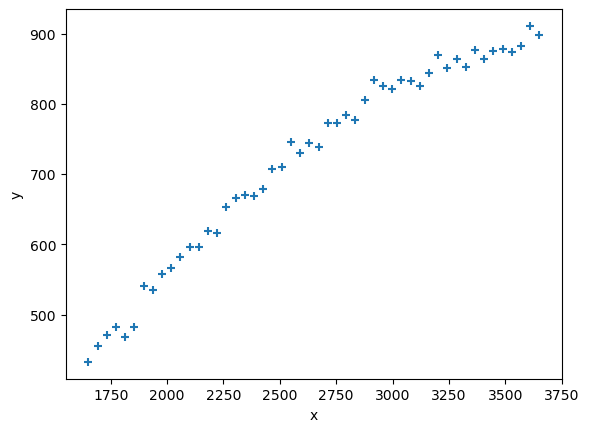

In [22]:
plt.scatter(X, y, marker='+')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [23]:
# Split the dataset into 605 training, and remaining 40% for testing and cross validation
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.40, random_state=1)

# Split 40% subset above into 2: corss validation and test set
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.50, random_state=1)

X_train.shape, y_train.shape, X_cv.shape, X_test.shape, y_cv.shape, y_test.shape

((30, 1), (30, 1), (10, 1), (10, 1), (10, 1), (10, 1))

Text(0.5, 1.0, 'Input vs Target')

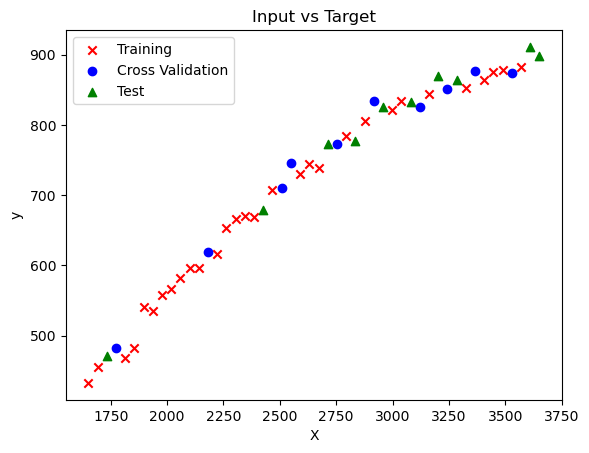

In [24]:
plt.scatter(X_train, y_train, marker='x', c='red', label='Training')
plt.scatter(X_cv, y_cv, marker='o', c='blue', label='Cross Validation')
plt.scatter(X_test, y_test, marker='^', c='green', label='Test')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Input vs Target')

Computed mean of the training set: 2504.06
Computed standard deviation of the training set : 574.85


Text(0.5, 1.0, 'Scaled Input vs Target')

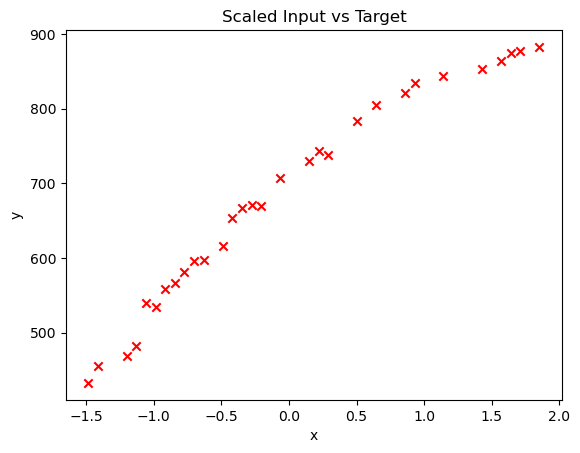

In [26]:
# Feature scaling
scalar_linear = StandardScaler()

# compute the mean and standard deviation of the training set then transform it
X_train_scaled = scalar_linear.fit_transform(X_train)

print(f"Computed mean of the training set: {scalar_linear.mean_.squeeze():.2f}")
print(f"Computed standard deviation of the training set : {scalar_linear.scale_.squeeze():.2f}")

# Plot the results
plt.scatter(X_train_scaled, y_train, marker='x', c='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scaled Input vs Target')

In [27]:
# Initialie the class
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [31]:
# Feed the scaled training set and get the predictions
y_hat = linear_model.predict(X_train_scaled)

# Use scikit-learn's utility function and divdie y 2
print(f'Trainig Mean Squared Error: {mean_squared_error(y_train, y_hat)/2}')

# For loop implementation
total_squred_error = 0.0
for i in range(len(y_train)):
    squared_error = (y_train[i] - y_hat[i])**2
    total_squred_error += squared_error
mse = total_squred_error/(2*len(y_train))

print(f'Training Mean Squared Error: {mse}')

Trainig Mean Squared Error: 406.19374192533155
Training Mean Squared Error: [406.19374193]


In [33]:
# Scale the corss validation set using the mean and standard deviation of the training set
X_cv_scaled = scalar_linear.fit_transform(X_cv)

print(f"Mean used to scale the CV set : {scalar_linear.mean_.squeeze():.2f}")
print(f"Standard deviation used to scale the CV set : {scalar_linear.scale_.squeeze():.2f}")

# Feed the scaled cross validation set
yhat = linear_model.predict(X_cv_scaled)

# Use scikit-learn's utility function and divide by 2
print(f"Cross validation MSE : {mean_squared_error(y_cv, yhat)/2}")

Mean used to scale the CV set : 2793.86
Standard deviation used to scale the CV set : 524.30
Cross validation MSE : 3696.781174313864


In [34]:
# Polynomail features

# Initiate the class to make polynomal features
poly = PolynomialFeatures(degree=2, include_bias=False)

# Comput the number of features and transform the training set
X_train_mapped = poly.fit_transform(X_train)

print(X_train_mapped[:5])

[[3.32446939e+03 1.10520967e+07]
 [2.34487755e+03 5.49845073e+06]
 [3.48773469e+03 1.21642933e+07]
 [2.63059184e+03 6.92001341e+06]
 [2.58977551e+03 6.70693719e+06]]


In [35]:
# Intialize the class
scaler_ploy = StandardScaler()

# Compute the mean and standard deviation of the training set then transform it
X_train_mapped_scaled = scaler_ploy.fit_transform(X_train_mapped)

# Preview the first 5 elements of the scaled training set
print(X_train_mapped_scaled[:5])

[[ 1.42715997  1.47236856]
 [-0.27691164 -0.36461881]
 [ 1.71117191  1.84025141]
 [ 0.22010925  0.1055935 ]
 [ 0.14910627  0.03511397]]


In [37]:
# Initialize the class
model = LinearRegression()

# Train the model
model.fit(X_train_mapped_scaled, y_train)

# Compute the training MSE
yhat = model.predict(X_train_mapped_scaled)
print(f"Training MSE : {mean_squared_error(y_train, yhat)/2}")

# Add the polynomial features to the cross validation set
X_cv_mapped = poly.transform(X_cv)

# Scale the cross validation set using the mean and standard deviation of the training set
X_cv_mapped_scaled = scaler_ploy.transform(X_cv_mapped)

# Compute the cross validation MSE
yhat = model.predict(X_cv_mapped_scaled)
print(f"Cross validation MSE : {mean_squared_error(y_cv, yhat)/2}")

Training MSE : 49.11160933402513
Cross validation MSE : 87.6984121111191


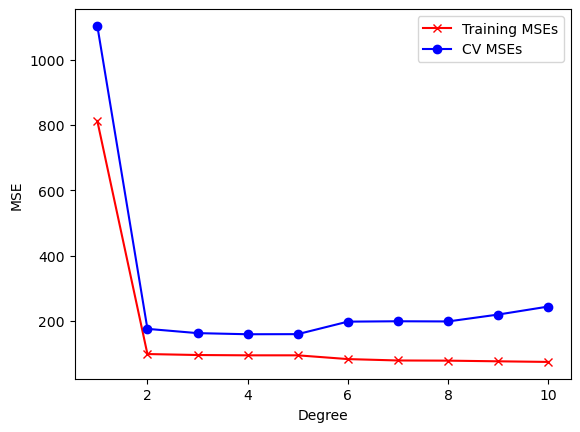

In [40]:
train_mses = []
cv_mses = []
models = []
polys = []
scalars = []

# Loop over 10 time each adding one more degree of polynomial higher
for degree in range(1, 11):
    poly = PolynomialFeatures(degree, include_bias=False)
    X_train_mapped = poly.fit_transform(X_train)

    # Scale the training set
    scalar_poly = StandardScaler()
    X_train_mapped_scaled = scalar_poly.fit_transform(X_train_mapped)

    # Create and train the model
    model = LinearRegression()
    model.fit(X_train_mapped_scaled, y_train)

    # Compute the training MSE
    y_hat = model.predict(X_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, y_hat)
    train_mses.append(train_mse)

    # Add polynomial features and scale the cross valdiation set
    X_cv_mapped = poly.transform(X_cv)
    X_cv_mapped_scaled = scalar_poly.transform(X_cv_mapped)
    
    # Compute the validation MSE
    y_hat = model.predict(X_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, y_hat)
    cv_mses.append(cv_mse)
    
    polys.append(poly)
    scalars.append(scalar_poly)
    models.append(model)

# plot the results
degree = range(1, 11)
plt.plot(degree, train_mses, marker='x', c='red', label='Training MSEs')
plt.plot(degree, cv_mses, marker='o', c='blue', label='CV MSEs')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.legend()

In [44]:
degree = np.argmin(cv_mses)+1

print(f"Lowest CV MSE is found in the model with degree={degree}")

Lowest CV MSE is found in the model with degree=4


In [45]:
# Test it on test dataset

# Add polynomial features to the test set
X_test_mapped = polys[degree-1].transform(X_test)
X_test_mapped_scaled = scalars[degree-1].transform(X_test_mapped)

# Compute the test MSE
y_hat = models[degree-1].predict(X_test_mapped_scaled)
test_mse = mean_squared_error(y_test, y_hat)

print(f"Training MSE : {train_mses[degree-1]:.2f}")
print(f"Cross Validation MSE: {cv_mses[degree-1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

Training MSE : 94.29
Cross Validation MSE: 158.86
Test MSE: 209.26
